# Analysis

### 1. Import thư viện cần thiết và load data

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

true_target = pd.read_csv("../data/preprocessed/data_test.csv")["throughput_down_mbps"]
pred_baseline = pd.read_csv("../data/prediction-baseline/prediction_baseline.csv")
pred_linear_regression = pd.read_csv("../data/prediction-linear-regression/prediction_linear_regression.csv")

model = joblib.load("../models/linear_regression_model.joblib")

### 2. Tạo bảng so sánh giữa hai mô hình Mean và Linear Regression

In [21]:
models_performance = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression'],
    'MAE': [mean_absolute_error(true_target, pred_baseline), mean_absolute_error(true_target, pred_linear_regression)],
    'RMSE': [root_mean_squared_error(true_target, pred_baseline), root_mean_squared_error(true_target, pred_linear_regression)],
    'R^2': [r2_score(true_target, pred_baseline), r2_score(true_target, pred_linear_regression)]
})

display(models_performance)

,Model,MAE,RMSE,R^2
0,Baseline (Mean),40.676235,42.340932,-0.003444
1,Linear Regression,7.203437,10.900410,0.933494


#### Ý nghĩa
- Mean Absolute Error (MAE): Trên trung bình, dự đoán của mô hình Linear Regression lệch khỏi giá trị đúng ~7.2 Mbps, rất gần so với mức lệch ~40.68 Mbps của mô hình Mean.
- Root Mean Squared Error (RMSE): Mô hình Linear Regression lệch khỏi giá trị đúng ít hơn mô hình Mean.
- Coefficient of determination (R^2): Mô hình Linear Regression phản ánh tốt sự biến thiên của thông lượng, trong khi mô hình Mean hầu như không phản ánh được điều này.

### 3. Phân tích coefficients của các biến đầu vào

Mô hình có y-intercept: -31.504708394830992


,Feature,Coefficient
0,distance_m,-0.021684
1,signal_mean_pct,1.093367
2,rx_link_rate_mean,0.040383
3,rtt_mean_ms,-0.005455
4,jitter_ms,-0.001275
5,packet_loss_pct,-0.105101


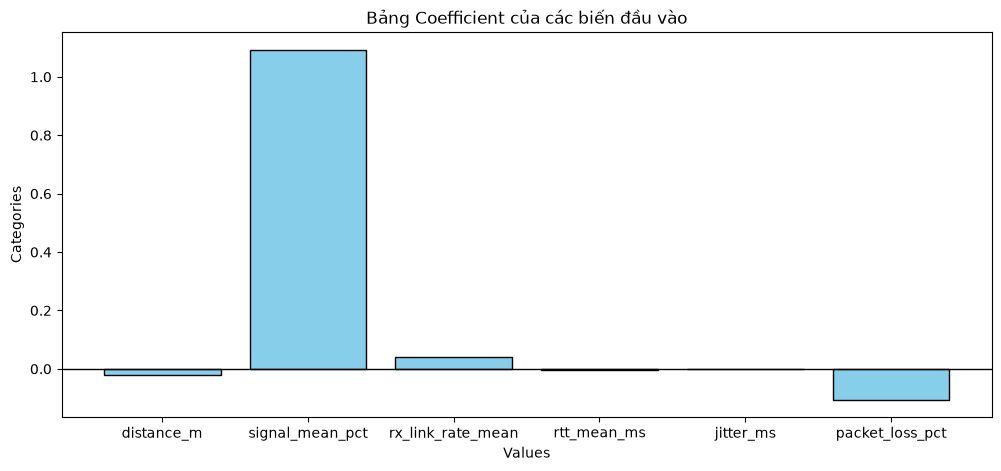

In [29]:
y_intercept = model.intercept_
coeff_table = pd.DataFrame({
    'Feature': model.feature_names_in_,
    'Coefficient': model.coef_
})

print("Mô hình có y-intercept:", y_intercept)
display(coeff_table)

plt.figure(figsize=(12, 5))
plt.bar(coeff_table['Feature'], coeff_table['Coefficient'], color='skyblue', edgecolor='black')
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Bảng Coefficient của các biến đầu vào')
plt.xlabel('Values')
plt.ylabel('Categories')

plt.savefig("../media/06_03.png", dpi=300, bbox_inches='tight')
plt.show()

#### Ý nghĩa
- `distance_m`: Cứ mỗi 1 mét đi xa khỏi Access Point, thông lượng sẽ mất đi ~0.022 Mbps
- `signal_mean_pct`: Cường độ tín hiệu tăng thêm 1% thì thông lượng sẽ tăng thêm ~1.093 Mbps
- `rx_link_rate`: Tốc độ liên kết tăng thêm 1 Mbps thì thông lượng sẽ tăng thêm ~0.04 Mbps
- `rtt_mean_ms`: Thời gian trễ trọn vòng tăng thêm 1 mili-giây thì thông lượng sẽ giảm đi ~0.005 Mbps
- `jitter_ms`: Biến thiên độ trễ tăng thêm 1 mili-giây thì thông lượng sẽ giảm đi ~0.001 Mbps
- `packet_loss_pct`: Tỷ lệ mất gói tin tăng thêm 1% thì thông lượng sẽ giảm đi ~0.105 Mbps